# Parcial 1A 



In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('spotify-2023.csv', encoding='latin-1')

print("Variables categóricas (object):", len(df.select_dtypes(include=['object']).columns))
print("Variables numéricas:", len(df.select_dtypes(include=['int64', 'float64']).columns))

Variables categóricas (object): 7
Variables numéricas: 17


A) Cargue los datos e identifique cuantas variables categóricas(tipo object) y cuantas variables
numéricas tiene.

In [10]:
df.info()
df.dtypes.value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

int64     17
object     7
Name: count, dtype: int64

B. Desarrolle un algoritmo que nos diga cuantas canciones de Taylor Swift hay en la base de
datos.

In [15]:
algoritmoA=df[df['artist(s)_name']=='Taylor Swift']
algoritmoA.value_counts()



track_name                                           artist(s)_name  artist_count  released_year  released_month  released_day  in_spotify_playlists  in_spotify_charts  streams     in_apple_playlists  in_apple_charts  in_deezer_playlists  in_deezer_charts  in_shazam_charts  bpm  key  mode   danceability_%  valence_%  energy_%  acousticness_%  instrumentalness_%  liveness_%  speechiness_%
All Of The Girls You Loved Before                    Taylor Swift    1             2019           8               23            1282                  6                  185240616   26                  6                19                   0                 5                 96   D    Major  72              40         47        71              0                   13          4                1
Anti-Hero                                            Taylor Swift    1             2022           10              21            9082                  56                 999748277   242                 142         

In [17]:
print(algoritmoA['artist(s)_name'].value_counts())

artist(s)_name
Taylor Swift    34
Name: count, dtype: int64


hay 34 cancionews de Taylor Swift en la base de datos.

C. Encuentre la media de cada columna numérica en la base de datos. (Reporte solo la media de
cada variable)

In [ ]:

numericMedia = df.select_dtypes(include=['int64', 'float64']).mean()
print(numericMedia)

D. Desarrolle una función que reciba como parámetro su base de datos y un año de
lanzamiento y le devuelva la lista de todas las canciones lanzadas antes año

In [18]:

def canciones_antes_año(df, año):
    return df[df['released_year'] < año][['track_name', 'released_year']]


print(canciones_antes_año(df, 2020))

                                        track_name  released_year
3                                     Cruel Summer           2019
22                                I Wanna Be Yours           2013
37                                     Blank Space           2014
38                                           Style           2014
41   Sunflower - Spider-Man: Into the Spider-Verse           2018
..                                             ...            ...
910                                  The Scientist           2002
911                                         Sparks           2000
914                                        Selfish           2016
922                                       Miss You           1982
923                     we fell in love in october           2018

[220 rows x 2 columns]


E. Cree una tabla con una función de agregación, que cuente cuantas canciones
hay de Taylor Swift y cuantas hay de Adele en la base de datos.

F. Desarrolle un subplot con dos gráficos, el primero es un boxplot relacione
artist_count (eje x) con streams, y el segundo un histograma de los años de
lanzamiento

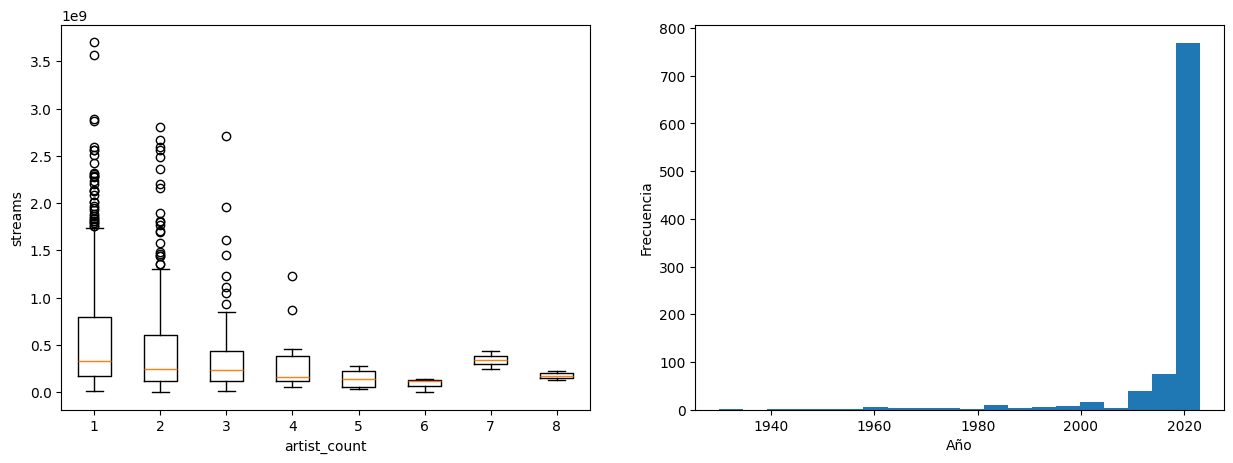

In [ ]:

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5))

df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
df['artist_count'] = pd.to_numeric(df['artist_count'], errors='coerce')

datos_box = [group['streams'].dropna() for name, group in df.groupby('artist_count')]
a1.boxplot(datos_box)
a1.set_xlabel('artist_count')
a1.set_ylabel('streams')

a2.hist(df['released_year'], bins=20)
a2.set_xlabel('Año')
a2.set_ylabel('Frecuencia')

plt.show()